In [46]:
import matplotlib.pyplot as plt
import numpy as np 
import polars as pl
# import plotly.graph_objects as go

import seaborn as sns
from settings import load_settings

settings = load_settings()

In [13]:
mttu_mttr_df = pl.read_parquet(f"{settings.mttu_mttr_path}/*.parquet")
staleness_df = pl.read_parquet(settings.feature_repo_age_and_staleness_path)


In [14]:
staleness_df.head()

package_name,github_repo,repo_age_years,commit_staleness_days
str,str,f64,i64
"""tabicl""","""soda-inria/tabicl""",1.1,0
"""django-tagulous""","""radiac/django-tagulous""",10.85,266
"""requests-oidc""","""tsweeney-dust/requests-oidc""",3.18,1026
"""interop""","""illumina/interop""",10.14,93
"""aiocaldav""","""thomaschiroux/aiocaldav""",7.75,2789


In [15]:
mttu_mttr_df.head()

package_name,snapshot_start,snapshot_end,avg_ttu,avg_ttr
str,datetime[ns],datetime[ns],f64,f64
"""aamp""",2019-04-22 22:37:52,2020-01-17 20:37:29,7.559755,0.0
"""abeci""",2022-04-13 03:35:55,2022-04-13 03:51:05,0.0,0.0
"""abeci""",2022-04-13 03:51:05,2022-04-13 03:56:48,0.0,0.0
"""abipy""",2018-08-21 22:13:27,2020-05-29 09:26:31,8.18377,0.0
"""abipy""",2020-05-29 09:26:31,2021-05-31 23:18:00,4.218481,0.0


In [16]:
combined_df = mttu_mttr_df.join(staleness_df, on="package_name")

critical_packages = combined_df.filter(
    (pl.col("commit_staleness_days") > 180) & 
    (pl.col("avg_ttu") > 30)
)

analyzed_df = combined_df.with_columns(
    pl.when(pl.col("repo_age_years") < 2).then(pl.lit("New"))
    .when(pl.col("repo_age_years") < 5).then(pl.lit("Mature"))
    .otherwise(pl.lit("Legacy")).alias("repo_maturity")
)

/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


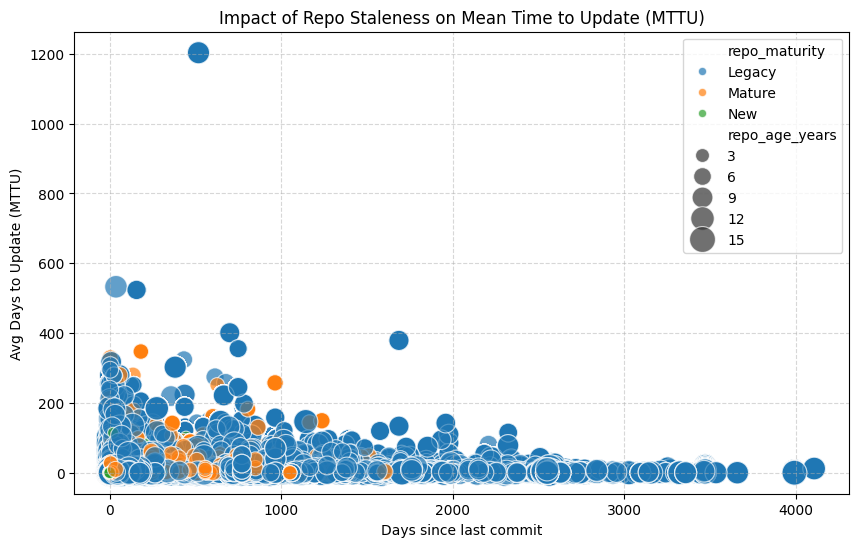

In [17]:
plot_df = analyzed_df.to_pandas()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df, 
    x="commit_staleness_days", 
    y="avg_ttu", 
    hue="repo_maturity", 
    size="repo_age_years",
    sizes=(40, 400), 
    alpha=0.7
)

plt.title("Impact of Repo Staleness on Mean Time to Update (MTTU)")
plt.xlabel("Days since last commit")
plt.ylabel("Avg Days to Update (MTTU)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

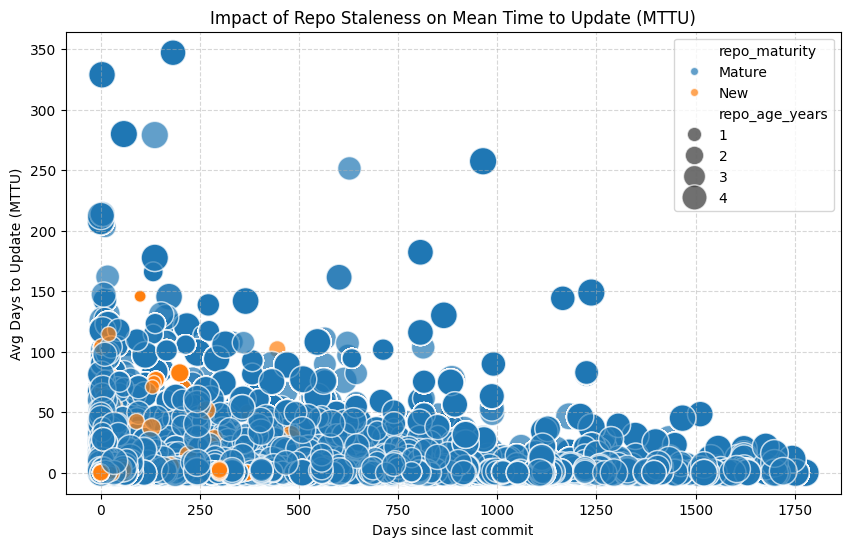

In [41]:

fil_plot_df = analyzed_df.filter(analyzed_df["repo_maturity"] != "Legacy").to_pandas()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=fil_plot_df, 
    x="commit_staleness_days", 
    y="avg_ttu", 
    hue="repo_maturity", 
    size="repo_age_years",
    sizes=(40, 400), 
    alpha=0.7
)

plt.title("Impact of Repo Staleness on Mean Time to Update (MTTU)")
plt.xlabel("Days since last commit")
plt.ylabel("Avg Days to Update (MTTU)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

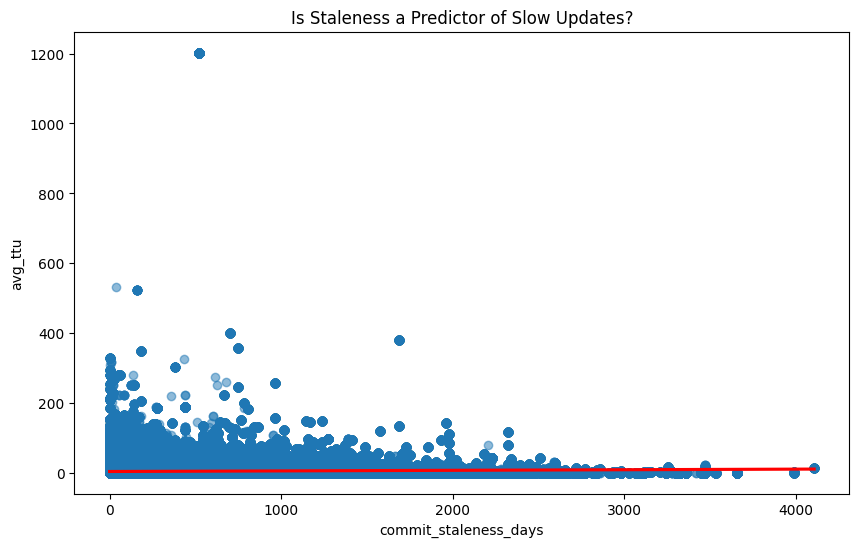

In [20]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=plot_df, 
    x="commit_staleness_days", 
    y="avg_ttu", 
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)
plt.title("Is Staleness a Predictor of Slow Updates?")
plt.show()


/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


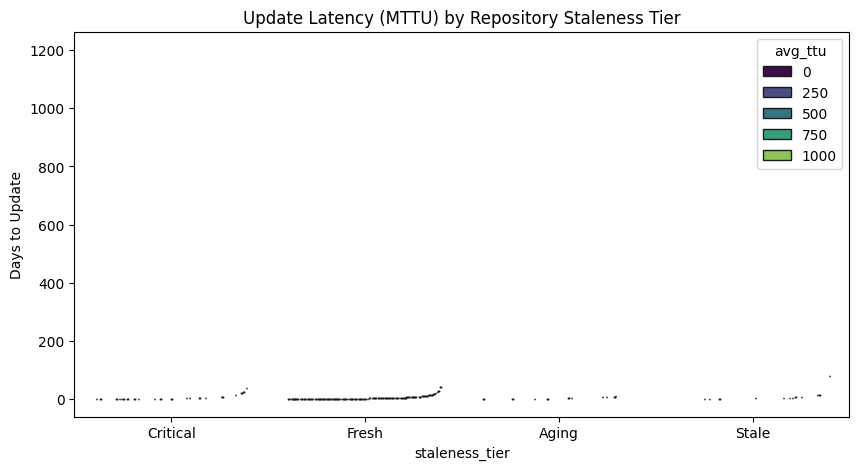

In [26]:
df = pl.from_pandas(plot_df)
df = df.with_columns(
    (pl.col("commit_staleness_days") * pl.col("avg_ttr")).alias("maintenance_debt_score")
)

df = df.with_columns(
    pl.col("commit_staleness_days").cut(
        breaks=[30, 90, 180], 
        labels=["Fresh", "Aging", "Stale", "Critical"]
    ).alias("staleness_tier")
)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df.to_pandas(), x="staleness_tier", y="avg_ttu", palette="viridis", hue="avg_ttu")
plt.title("Update Latency (MTTU) by Repository Staleness Tier")
plt.ylabel("Days to Update")
plt.show()

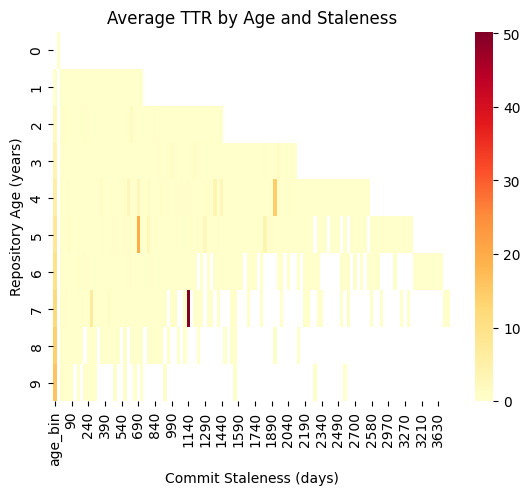

In [43]:
grid_df = combined_df.with_columns([
    (pl.col("repo_age_years") // 2 * 2).alias("age_bin"),
    (pl.col("commit_staleness_days") // 30 * 30).alias("stale_bin")
]).group_by(["age_bin", "stale_bin"]).agg(pl.col("avg_ttr").mean())
sorted_grid_df = grid_df.sort(["age_bin", "stale_bin"])

pivot_df = sorted_grid_df.pivot(values="avg_ttr", index="age_bin", on="stale_bin")
ax = sns.heatmap(pivot_df.to_pandas(), cmap="YlOrRd")
ax.set_xlabel("Commit Staleness (days)")
ax.set_ylabel("Repository Age (years)")
ax.set_title("Average TTR by Age and Staleness")
plt.show()

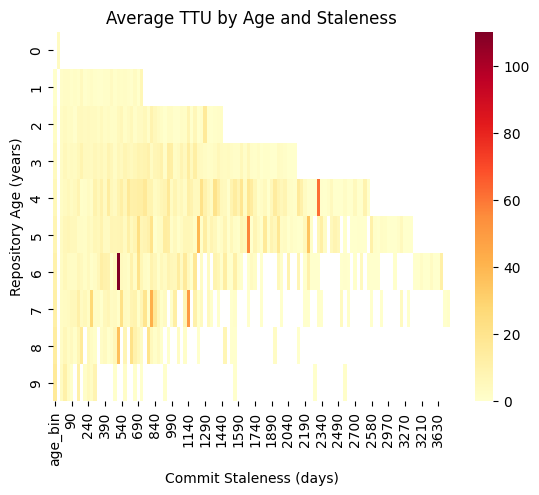

In [58]:
grid_df = combined_df.with_columns([
    (pl.col("repo_age_years") // 2 * 2).alias("age_bin"),
    (pl.col("commit_staleness_days") // 30 * 30).alias("stale_bin")
]).group_by(["age_bin", "stale_bin"]).agg(pl.col("avg_ttu").mean())
sorted_grid_df = grid_df.sort(["age_bin", "stale_bin"])

pivot_df = sorted_grid_df.pivot(values="avg_ttu", index="age_bin", on="stale_bin")
ax = sns.heatmap(pivot_df.to_pandas(), cmap="YlOrRd")
ax.set_xlabel("Commit Staleness (days)")
ax.set_ylabel("Repository Age (years)")
ax.set_title("Average TTU by Age and Staleness")
plt.show()

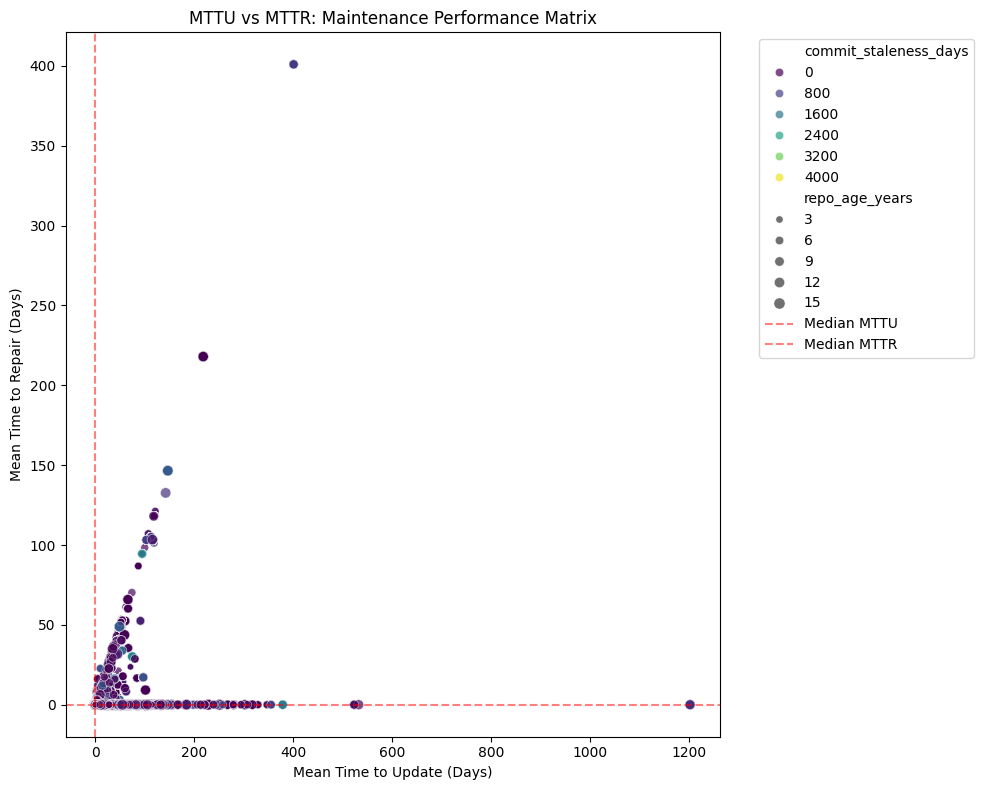

In [35]:
mttu_median = df.select(pl.median("avg_ttu")).item()
mttr_median = df.select(pl.median("avg_ttr")).item()

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=plot_df, 
    x="avg_ttu", 
    y="avg_ttr", 
    hue="commit_staleness_days",
    size="repo_age_years",
    palette="viridis",
    alpha=0.7
)

plt.axvline(mttu_median, color='red', linestyle='--', alpha=0.5, label="Median MTTU")
plt.axhline(mttr_median, color='red', linestyle='--', alpha=0.5, label="Median MTTR")

plt.title("MTTU vs MTTR: Maintenance Performance Matrix")
plt.xlabel("Mean Time to Update (Days)")
plt.ylabel("Mean Time to Repair (Days)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

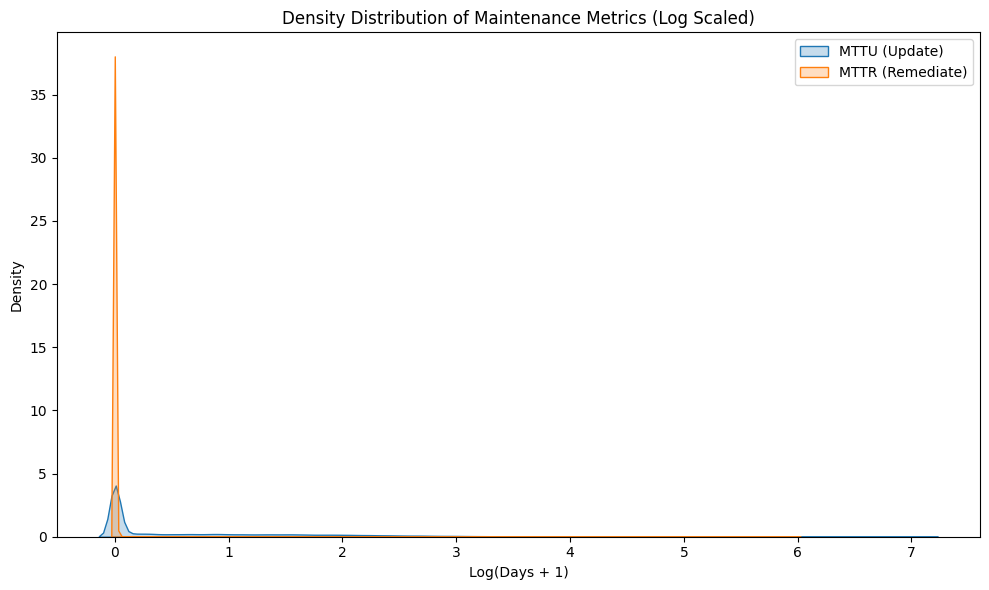

In [48]:
plot_df['log_mttu'] = np.log1p(plot_df['avg_ttu'])
plot_df['log_mttr'] = np.log1p(plot_df['avg_ttr'])

plt.figure(figsize=(10, 6))
sns.kdeplot(data=plot_df, x="log_mttu", label="MTTU (Update)", fill=True)
sns.kdeplot(data=plot_df, x="log_mttr", label="MTTR (Remediate)", fill=True)
plt.title("Density Distribution of Maintenance Metrics (Log Scaled)")
plt.xlabel("Log(Days + 1)")
plt.legend()
plt.tight_layout()
plt.show()

/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


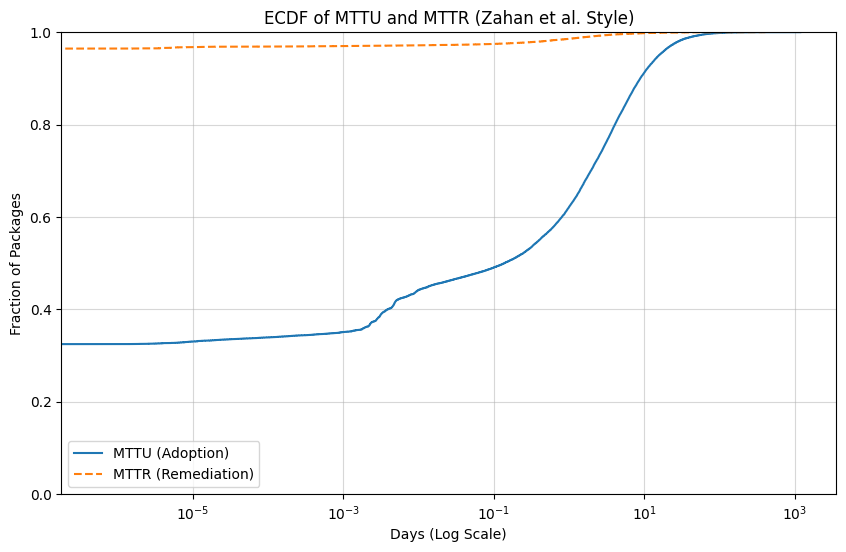

In [53]:
plt.figure(figsize=(10, 6))
sns.ecdfplot(data=plot_df, x="avg_ttu", label="MTTU (Adoption)")
sns.ecdfplot(data=plot_df, x="avg_ttr", label="MTTR (Remediation)", linestyle="--")

plt.xscale('log')
plt.title("ECDF of MTTU and MTTR (Zahan et al. Style)")
plt.xlabel("Days (Log Scale)")
plt.ylabel("Fraction of Packages")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()


In [55]:
df.columns

['package_name',
 'snapshot_start',
 'snapshot_end',
 'avg_ttu',
 'avg_ttr',
 'github_repo',
 'repo_age_years',
 'commit_staleness_days',
 'ttr_age_ratio',
 'remediation_speed']

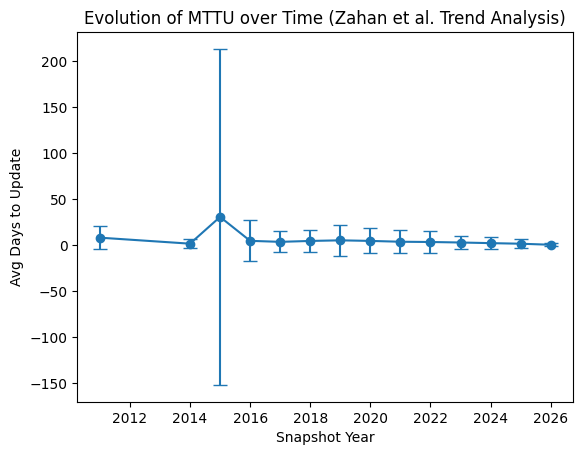

In [56]:
yearly_trend = df.with_columns(
    pl.col("snapshot_start").dt.year().alias("year")
).group_by("year").agg([
    pl.col("avg_ttu").mean().alias("mean_mttu"),
    pl.col("avg_ttu").std().alias("std_mttu")
]).sort("year")

plt.errorbar(yearly_trend["year"], yearly_trend["mean_mttu"], 
             yerr=yearly_trend["std_mttu"], fmt='-o', capsize=5)
plt.title("Evolution of MTTU over Time (Zahan et al. Trend Analysis)")
plt.xlabel("Snapshot Year")
plt.ylabel("Avg Days to Update")
plt.show()

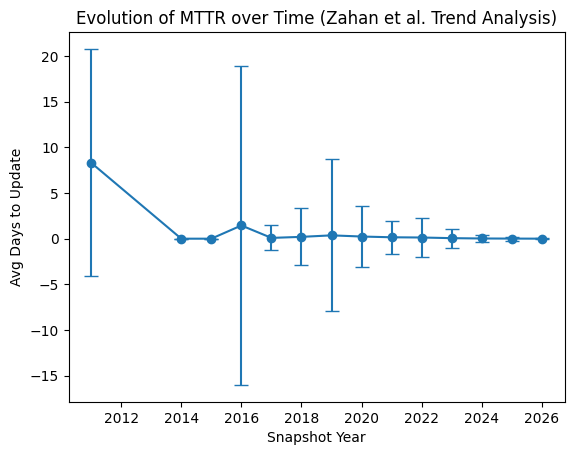

In [57]:
yearly_trend = df.with_columns(
    pl.col("snapshot_start").dt.year().alias("year")
).group_by("year").agg([
    pl.col("avg_ttr").mean().alias("mean_mttr"),
    pl.col("avg_ttr").std().alias("std_mttr")
]).sort("year")

plt.errorbar(yearly_trend["year"], yearly_trend["mean_mttr"], 
             yerr=yearly_trend["std_mttr"], fmt='-o', capsize=5)
plt.title("Evolution of MTTR over Time (Zahan et al. Trend Analysis)")
plt.xlabel("Snapshot Year")
plt.ylabel("Avg Days to Update")
plt.show()